In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Load all datasets
fraud_df = pd.read_csv(r'C:\CareerShieldAI\datasets\fake_job_postings.csv')
resume_df = pd.read_csv(r'C:\CareerShieldAI\datasets\Resume.csv')
it_jobs_df = pd.read_csv(r'C:\CareerShieldAI\datasets\IT_Job_Roles_Skills.csv', encoding='latin1')
jobs_df = pd.read_csv(r'C:\CareerShieldAI\datasets\JobsDatasetProcessed.csv', encoding='latin1')
all_jobs_df = pd.read_csv(r'C:\CareerShieldAI\datasets\all_job_post.csv', encoding='latin1')

print("All datasets loaded successfully!")
print(f"Fraud dataset:   {fraud_df.shape}")
print(f"Resume dataset:  {resume_df.shape}")
print(f"IT Jobs dataset: {it_jobs_df.shape}")
print(f"Jobs dataset:    {jobs_df.shape}")
print(f"All Jobs dataset:{all_jobs_df.shape}")

All datasets loaded successfully!
Fraud dataset:   (17880, 18)
Resume dataset:  (2484, 4)
IT Jobs dataset: (493, 4)
Jobs dataset:    (3000, 9)
All Jobs dataset:(1167, 5)


==== FRAUD DATASET EDA ====
Total jobs: 17880
Real jobs:  17014
Fake jobs:  866
Fraud %:    4.84%

==== MISSING VALUES ====
salary_range           83.96
department             64.58
required_education     45.33
benefits               40.34
required_experience    39.43
function               36.10
industry               27.42
employment_type        19.41
company_profile        18.50
requirements           15.08
location                1.94
description             0.01
dtype: float64


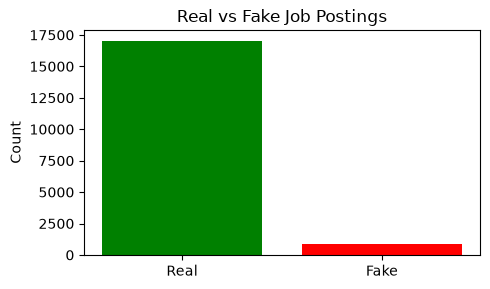

In [2]:
import matplotlib.pyplot as plt

# Count real vs fake jobs
fraud_counts = fraud_df['fraudulent'].value_counts()

# Print basic stats
print("==== FRAUD DATASET EDA ====")
print(f"Total jobs: {len(fraud_df)}")
print(f"Real jobs:  {fraud_counts[0]}")
print(f"Fake jobs:  {fraud_counts[1]}")
print(f"Fraud %:    {fraud_df['fraudulent'].mean()*100:.2f}%")

# Print missing value summary
print("\n==== MISSING VALUES ====")
# Calculate missing % for each column
missing = (fraud_df.isnull().sum() / len(fraud_df) * 100).round(2)
# Only show columns that have missing values
print(missing[missing > 0].sort_values(ascending=False))

# Plot real vs fake distribution
plt.figure(figsize=(5,3))                          # set chart size
plt.bar(['Real', 'Fake'], fraud_counts.values,     # create bar chart
        color=['green', 'red'])
plt.title('Real vs Fake Job Postings')             # chart title
plt.ylabel('Count')                                # y axis label
plt.tight_layout()                                 # fix layout spacing
plt.show()                                         # display chart

==== RESUME DATASET EDA ====
Total resumes: 2484
Categories:    24

==== RESUMES PER CATEGORY ====
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

==== SAMPLE RESUME TEXT ====
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager

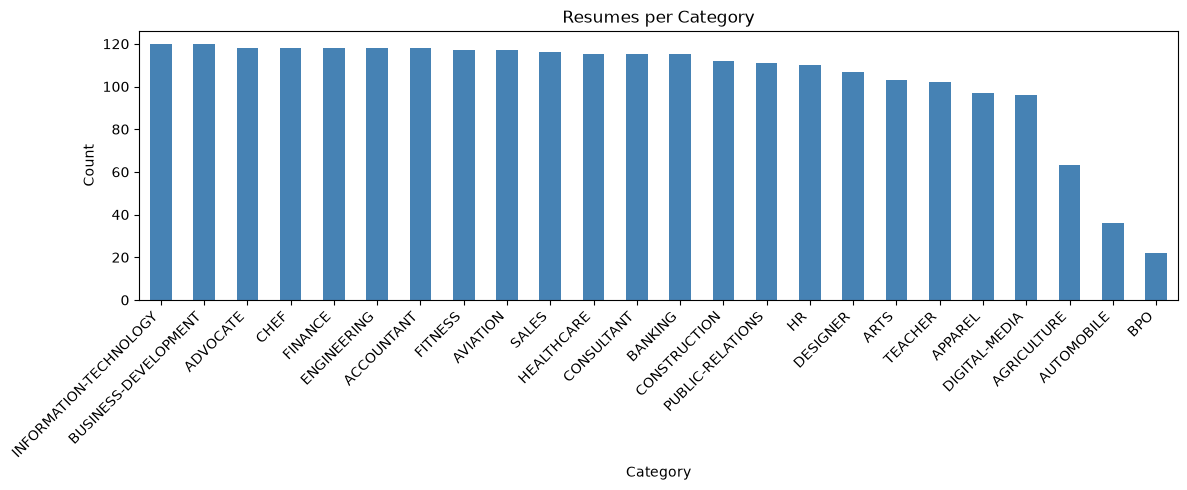

In [3]:
# ==== RESUME DATASET EDA ====
print("==== RESUME DATASET EDA ====")
print(f"Total resumes: {len(resume_df)}")          # total resume count
print(f"Categories:    {resume_df['Category'].nunique()}")  # unique job categories

# Show how many resumes per category
print("\n==== RESUMES PER CATEGORY ====")
print(resume_df['Category'].value_counts())        # count resumes in each category

# Show sample resume text (first 300 characters only)
print("\n==== SAMPLE RESUME TEXT ====")
print(resume_df['Resume_str'][0][:300])            # preview first resume

# Plot resume category distribution
plt.figure(figsize=(12,5))                         # wide chart for many categories
resume_df['Category'].value_counts().plot(         # bar chart of categories
    kind='bar', color='steelblue')
plt.title('Resumes per Category')                  # chart title
plt.xlabel('Category')                             # x axis label
plt.ylabel('Count')                                # y axis label
plt.xticks(rotation=45, ha='right')               # rotate x labels for readability
plt.tight_layout()                                 # fix layout spacing
plt.show()                                         # display chart

In [4]:
# ==== CAREER DATASETS EDA ====
print("==== IT JOB ROLES ====")
print(f"Total roles: {len(it_jobs_df)}")           # count of IT job roles
print(f"Columns: {list(it_jobs_df.columns)}")      # show column names

# Show first 3 job titles and their skills
print("\nSample roles:")
for i in range(3):                                 # loop through first 3 rows
    title = it_jobs_df['Job Title'][i]             # get job title
    skills = it_jobs_df['Skills'][i]               # get skills for that title
    print(f"\n→ {title}")                          # print title
    print(f"  Skills: {skills[:100]}...")           # print first 100 chars of skills

print("\n==== JOBS DATASET ====")
print(f"Total jobs: {len(jobs_df)}")               # count of jobs
print(f"Columns: {list(jobs_df.columns)}")         # show column names

print("\n==== ALL JOB POSTS ====")
print(f"Total posts: {len(all_jobs_df)}")          # count of job posts
print(f"Columns: {list(all_jobs_df.columns)}")     # show column names

# Show unique job categories
print("\nJob categories:")
print(all_jobs_df['category'].value_counts())      # count jobs per category

==== IT JOB ROLES ====
Total roles: 493
Columns: ['Job Title', 'Job Description', 'Skills', 'Certifications']

Sample roles:

→ Admin Big Data
  Skills: Hadoop, Spark, MapReduce, Data Lakes, Data Warehousing, Big Data Architecture, NoSQL, Data Modeling,...

→ Ansible Operations Engineer
  Skills: Ansible, Linux, Automation, Cloud Platforms, CI/CD, Infrastructure as Code, Kubernetes, Docker, AWS,...

→ Artifactory Administrator
  Skills: Artifactory, CI/CD, Jenkins, Docker, Maven, Gradle, Build Automation, Version Control, Git, Cloud Co...

==== JOBS DATASET ====
Total jobs: 3000
Columns: ['ID', 'Query', 'Job Title', 'Description', 'IT Skills', 'Soft Skills', 'Education', 'Experience', 'Token Usage']

==== ALL JOB POSTS ====
Total posts: 1167
Columns: ['job_id', 'category', 'job_title', 'job_description', 'job_skill_set']

Job categories:
category
INFORMATION-TECHNOLOGY    240
BUSINESS-DEVELOPMENT      239
FINANCE                   236
SALES                     232
HR                   

In [5]:
# ==== MERGE ALL 3 CAREER DATASETS INTO ONE ====

# --- Prepare dataset 1: IT Job Roles ---
df1 = it_jobs_df[['Job Title', 'Skills']].copy()  # keep only title and skills
df1.columns = ['job_title', 'skills']              # rename columns to standard names

# --- Prepare dataset 2: Jobs Dataset ---
df2 = jobs_df[['Job Title', 'IT Skills']].copy()  # keep only title and IT skills
df2.columns = ['job_title', 'skills']              # rename columns to standard names

# --- Prepare dataset 3: All Job Posts ---
df3 = all_jobs_df[['job_title', 'job_skill_set']].copy()  # keep title and skills
df3.columns = ['job_title', 'skills']              # rename columns to standard names

# --- Combine all 3 into one dataframe ---
career_df = pd.concat([df1, df2, df3], ignore_index=True)  # stack all rows together

# --- Clean up ---
career_df.dropna(inplace=True)                     # remove rows with missing values
career_df.drop_duplicates(inplace=True)            # remove duplicate rows
career_df.reset_index(drop=True, inplace=True)     # reset row numbers

# --- Save merged dataset ---
career_df.to_csv(r'C:\CareerShieldAI\datasets\career_skills.csv', index=False)  # save to file

print("==== MERGED CAREER DATASET ====")
print(f"Total rows:  {len(career_df)}")            # total job roles
print(f"Columns:     {list(career_df.columns)}")   # column names
print(f"\nSample:")
print(career_df.head(5))                           # show first 5 rows
print("\nSaved to datasets/career_skills.csv")

==== MERGED CAREER DATASET ====
Total rows:  4643
Columns:     ['job_title', 'skills']

Sample:
                                           job_title  \
0                                     Admin Big Data   
1                        Ansible Operations Engineer   
2                          Artifactory Administrator   
3  Artificial Intelligence / Machine Learning Leader   
4  Artificial Intelligence / Machine Learning Sr....   

                                              skills  
0  Hadoop, Spark, MapReduce, Data Lakes, Data War...  
1  Ansible, Linux, Automation, Cloud Platforms, C...  
2  Artifactory, CI/CD, Jenkins, Docker, Maven, Gr...  
3  AI Strategy, Machine Learning, Team Management...  
4  AI Strategy, Machine Learning, Team Management...  

Saved to datasets/career_skills.csv


In [6]:
# ==== CLEAN AND SAVE FRAUD DATASET ====

# --- Fill missing text columns with empty string ---
text_cols = ['title', 'description', 'requirements', 
             'company_profile', 'benefits']        # columns with text data

for col in text_cols:                              # loop through each text column
    fraud_df[col] = fraud_df[col].fillna('')       # replace missing with empty string

# --- Fill missing category columns with 'Unknown' ---
cat_cols = ['employment_type', 'required_experience', 
            'required_education', 'industry', 
            'function', 'department']              # columns with category data

for col in cat_cols:                               # loop through each category column
    fraud_df[col] = fraud_df[col].fillna('Unknown') # replace missing with Unknown

# --- Fill missing salary with 'Not Specified' ---
fraud_df['salary_range'] = fraud_df['salary_range'].fillna('Not Specified')  # fill salary

# --- Save cleaned fraud dataset ---
fraud_df.to_csv(r'C:\CareerShieldAI\datasets\fraud_cleaned.csv', index=False)  # save file

print("==== CLEANED FRAUD DATASET ====")
print(f"Total rows:    {len(fraud_df)}")           # total job postings
print(f"Fake jobs:     {fraud_df['fraudulent'].sum()}")   # count of fake jobs
print(f"Real jobs:     {(fraud_df['fraudulent']==0).sum()}") # count of real jobs
print(f"\nMissing values after cleaning:")
print(fraud_df.isnull().sum()[fraud_df.isnull().sum() > 0])  # show remaining nulls
print("\nSaved to datasets/fraud_cleaned.csv")

==== CLEANED FRAUD DATASET ====
Total rows:    17880
Fake jobs:     866
Real jobs:     17014

Missing values after cleaning:
location    346
dtype: int64

Saved to datasets/fraud_cleaned.csv


In [7]:
# ==== CLEAN AND SAVE RESUME DATASET ====

# --- Remove rows where resume text is empty ---
resume_df = resume_df[resume_df['Resume_str'].str.strip() != '']  # keep non-empty resumes

# --- Keep only useful columns ---
resume_clean = resume_df[['ID', 'Resume_str', 'Category']].copy()  # drop html column

# --- Reset row numbers ---
resume_clean.reset_index(drop=True, inplace=True)  # reset index after filtering

# --- Save cleaned resume dataset ---
resume_clean.to_csv(r'C:\CareerShieldAI\datasets\resume_cleaned.csv', index=False)  # save file

print("==== CLEANED RESUME DATASET ====")
print(f"Total resumes:  {len(resume_clean)}")      # total resumes
print(f"Categories:     {resume_clean['Category'].nunique()}")  # unique categories
print(f"\nSample:")
print(resume_clean.head(3))                        # show first 3 rows
print("\nSaved to datasets/resume_cleaned.csv")

==== CLEANED RESUME DATASET ====
Total resumes:  2483
Categories:     24

Sample:
         ID                                         Resume_str Category
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...       HR
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...       HR
2  33176873           HR DIRECTOR       Summary      Over 2...       HR

Saved to datasets/resume_cleaned.csv
